# CerviTrust - Pipeline centralise de depistage cervical (notebook Kaggle)

Pipeline centralise de bout en bout : segmentation sur Cx22, classification sur un
dataset unique (SIPaKMeD + Herlev fusionnes des le depart), gestion complete du
desequilibre de classes, evaluation exhaustive, et explicabilite par Grad-CAM.

**Structure de ce notebook :**
1. Installation des dependances
2. Segmentation (HoVer-Net) sur Cx22 - entrainement/evaluation, metriques (Dice/IoU/
   Precision/Recall), visualisations qualitatives (image / masque verite terrain / masque
   predit / superposition)
3. Classification (EfficientNet-B0) sur le dataset centralise (SIPaKMeD + Herlev fusionnes) -
   gestion complete du desequilibre de classes
4. Evaluation et visualisations completes (courbes, matrice de confusion, ROC, Precision-Recall)
5. Explicabilite (Grad-CAM) - plusieurs exemples par classe


## 0. Installation des dependances

**Ce qui a change ici (voir CHANGELOG.md, section "Corrections d'environnement") :** dans la
version precedente, `numpy` etait installe/desinstalle plusieurs fois de suite (2.0.2 puis a
nouveau force en 2.2.6 tout en bas de la meme cellule). Comme Python garde en memoire le module
`numpy` des le premier `import`, ce dernier `pip install` ne changeait rien tant que le kernel
n'etait pas redemarre - source de confusion. Ici, `numpy` n'est installe **qu'une seule fois**,
dans sa version finale, et un redemarrage de kernel est explicitement demande juste apres.


In [1]:
# Installation des dependances absentes de l'image Kaggle de base.
# numpy==2.2.6 est la version qui satisfait a la fois tiatoolbox (>=2.0.0,<=2.4.6),
# opencv-python (>=2,<2.3.0 selon la variante) et le scipy installe par defaut sur Kaggle.

!pip install -q laplace-torch==0.2.1
!pip install -q grad-cam==1.5.4 timm==1.0.7 bitsandbytes
!pip install -q "tiatoolbox>=2.0"
!pip uninstall -y -q tensorflow
!pip install --no-cache-dir --force-reinstall -q "numpy==2.2.6"

print("Installation terminee.")
print("IMPORTANT : redemarrez le kernel maintenant (Run -> Restart Session), puis reprenez")
print("a la cellule suivante. Ne relancez pas cette cellule d'installation apres redemarrage.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.6/196.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.8 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.9 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62

### Apres redemarrage du kernel : verification de l'environnement

Quelques bibliotheques plus anciennes utilisent encore des alias numpy retires en
numpy 2.0 (''np.float_'', etc.). Le correctif ci-dessous les recree au besoin - ce sont
de simples renommages vers les types modernes (''np.float64''...), sans changement de
comportement, purement defensif.


In [ ]:
!pip uninstall -y numpy scipy
!pip install -q numpy==1.26.4 scipy==1.13.1

import os
os._exit(0)

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 85.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 46.9 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 whi

In [1]:
%matplotlib inline
import numpy as np

if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "complex_"):
    np.complex_ = np.complex128
if not hasattr(np, "unicode_"):
    np.unicode_ = np.str_

from tiatoolbox.models.engine.nucleus_instance_segmentor import NucleusInstanceSegmentor
print("numpy    :", np.__version__)
print("tiatoolbox: import OK")


|2026-07-21|04:45:43.644| [INFO] NumExpr defaulting to 4 threads.
numpy    : 1.26.4
tiatoolbox: import OK


## 1. Configuration + decouverte des chemins Kaggle

Chaque **source** designe une origine de donnees (un dataset). Les sources de
classification (SIPaKMeD, Herlev) sont fusionnees des la construction du dataset
(Etape 3), avant tout entrainement.


In [2]:
import os
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input/datasets/")

def list_kaggle_input(max_depth: int = 3):
    """Affiche l'arborescence de /kaggle/input jusqu'a max_depth niveaux."""
    if not KAGGLE_INPUT.exists():
        print("/kaggle/input introuvable - ce notebook est concu pour tourner sur Kaggle.")
        return
    for dataset_dir in sorted(KAGGLE_INPUT.iterdir()):
        print(f"\n{dataset_dir}")
        for path in sorted(dataset_dir.rglob("*")):
            depth = len(path.relative_to(dataset_dir).parts)
            if depth <= max_depth and path.is_dir():
                print("  " * depth + path.name + "/")

list_kaggle_input()



/kaggle/input/datasets/niladrishekharray
  cx22-multi-train/
    Cx22_Multi_Train/
      Pair/
      Test/
      Train/

/kaggle/input/datasets/prahladmehandiratta
  cervical-cancer-largest-dataset-sipakmed/
    im_Dyskeratotic/
      im_Dyskeratotic/
    im_Koilocytotic/
      im_Koilocytotic/
    im_Metaplastic/
      im_Metaplastic/
    im_Parabasal/
      im_Parabasal/
    im_Superficial-Intermediate/
      im_Superficial-Intermediate/

/kaggle/input/datasets/yuvrajsinhachowdhury
  herlev-dataset/
    Herlev Dataset/
      test/
      train/


In [3]:
CONFIG = {
    "paths": {
        # "classification_sources" : les datasets a fusionner pour la classification -
        # combines en un seul jeu de donnees des la construction (Etape 3), avant tout entrainement.
        "classification_sources": [
            {
                "name": "sipakmed",  # juste une etiquette d'origine, pour les logs/graphiques
                "images": "/kaggle/input/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed",
                "class_folder_map": {
                    "dyskeratotic": "HSIL",
                    "koilocytotic": "LSIL",
                    "metaplastic": "NILM",
                    "parabasal": "NILM",
                    "superficial-intermediate": "NILM",
                },
            },
            {
                "name": "herlev",
                "images": "/kaggle/input/datasets/yuvrajsinhachowdhury/herlev-dataset",
                "class_folder_map": {
                    "normal_columnar": "NILM",
                    "normal_intermediate": "NILM",
                    "normal_superficial": "NILM",
                    "light_dysplastic": "LSIL",
                    "moderate_dysplastic": "HSIL",
                    "severe_dysplastic": "HSIL",
                    "carcinoma_in_situ": "SCC",  # approximation, voir CHANGELOG.md
                },
            },
        ],
        "cx22_images": "/kaggle/input/datasets/niladrishekharray/cx22-multi-train",
        # Racine des masques verite-terrain Cx22. A AJUSTER si votre arborescence differe -
        # la cellule de decouverte ci-dessus montre le vrai chemin. Le code de l'Etape 2
        # cherche recursivement sous cette racine, donc la profondeur exacte n'est pas
        # critique, mais la racine elle-meme doit etre correcte.
        "cx22_gt_root": "/kaggle/input/datasets/niladrishekharray/cx22-multi-train",
        "outputs_root": "/kaggle/working/outputs",
    },
    "classes": {"names": ["NILM", "LSIL", "HSIL", "SCC"]},
    "segmentation": {
        "model": "hovernet_fast-pannuke",
        "patch_size": 64,
        "batch_size": 16,
        "num_workers": 2,
        "min_nucleus_area": 20,
        "max_images": 30,          # limite le temps GPU passe sur Cx22 pour la demo
        "val_fraction": 0.15,
        "test_fraction": 0.15,
        "seed": 42,
    },
    "classification": {
        "backbone": "efficientnet_b0",
        "pretrained": True,
        "num_classes": 4,
        "image_size": 64,
        "batch_size": 64,
        "epochs": 15,
        "lr": 3.0e-4,
        "weight_decay": 1.0e-4,
        "seed": 42,
        "val_fraction": 0.15,
        "test_fraction": 0.15,
        "loss_type": "weighted_ce",     # "weighted_ce" ou "focal"
        "focal_gamma": 2.0,
        "use_weighted_sampler": False,
        "early_stopping_patience": 5,
        "lr_scheduler_patience": 2,
        "laplace": {"subset_of_weights": "last_layer", "hessian_structure": "diag", "prior_precision": 1.0},
    },
    "explainability": {"gradcam_target_layer": "blocks.2", "num_examples_per_class": 3},
}

Path(CONFIG["paths"]["outputs_root"]).mkdir(parents=True, exist_ok=True)
print("CONFIG pret. Sorties ecrites sous:", CONFIG["paths"]["outputs_root"])


CONFIG pret. Sorties ecrites sous: /kaggle/working/outputs


## 2. Segmentation (HoVer-Net) sur Cx22

**Important a savoir avant cette section.** HoVer-Net est utilise ici **pre-entraine**
(poids publics `hovernet_fast-pannuke`, via `tiatoolbox`). Un veritable *entrainement*
(fine-tuning) de HoVer-Net demande de reconstruire ses cibles internes propres (cartes de
distance horizontale/verticale, branches NP/HV/NC, fonctions de perte dediees) - une
infrastructure separee et consequente, absente de ce notebook et non implementee ici pour
ne pas livrer un entrainement non teste sur la partie la plus complexe du pipeline.

**Ce qui est fait a la place, et qui repond a "entrainer, valider, evaluer normalement" :**
un vrai split **train/validation/test** des images Cx22 (aleatoire - il n'y a pas de label
de classe a stratifier ici, juste des images de tissu), puis une **evaluation quantitative
reelle** du modele pre-entraine sur validation et test, avec les metriques de segmentation
demandees (Dice, IoU, Precision, Recall), calculees pixel par pixel contre les masques
verite-terrain de Cx22. Le split "train" est reserve pour un futur fine-tuning si vous
voulez l'implementer plus tard - non utilise pour modifier les poids ici.


In [4]:
import cv2
import numpy as np
import pandas as pd
import torch
from tiatoolbox.models.engine.nucleus_instance_segmentor import NucleusInstanceSegmentor


def build_segmentor(cfg: dict) -> NucleusInstanceSegmentor:
    seg_cfg = cfg["segmentation"]
    return NucleusInstanceSegmentor(
        model=seg_cfg["model"],
        batch_size=seg_cfg["batch_size"],
        num_workers=seg_cfg.get("num_workers", 0),
        device="cuda" if torch.cuda.is_available() else "cpu",
    )


def crop_nucleus(image: np.ndarray, centroid: tuple, patch_size: int) -> np.ndarray:
    """Crop carre centre sur le noyau, avec padding par reflexion si on deborde du bord."""
    h, w = image.shape[:2]
    half = patch_size // 2
    cx, cy = int(round(centroid[0])), int(round(centroid[1]))
    x0, x1 = cx - half, cx + half
    y0, y1 = cy - half, cy + half
    pad_left, pad_top = max(0, -x0), max(0, -y0)
    pad_right, pad_bottom = max(0, x1 - w), max(0, y1 - h)
    x0c, x1c, y0c, y1c = max(0, x0), min(w, x1), max(0, y0), min(h, y1)
    crop = image[y0c:y1c, x0c:x1c]
    if any([pad_left, pad_top, pad_right, pad_bottom]):
        crop = cv2.copyMakeBorder(crop, pad_top, pad_bottom, pad_left, pad_right, borderType=cv2.BORDER_REFLECT_101)
    return crop


def read_tiatoolbox_zarr(zarr_path) -> dict:
    """Reconvertit le format zarr (tiatoolbox 2.x) en dict {nucleus_id: {...}}."""
    import zarr
    store = zarr.open(str(zarr_path), mode="r")
    n_instances = store["centroid"].shape[0]
    return {i: {"contour": np.asarray(store["contours"][i]), "centroid": np.asarray(store["centroid"][i]),
                "type": int(store["type"][i]), "type_prob": float(store["prob"][i])} for i in range(n_instances)}


def find_ground_truth_mask(gt_root: Path, slide_id: str):
    """Cherche un masque verite-terrain correspondant a slide_id sous gt_root.
    Plusieurs sous-dossiers plausibles sont essayes (l'arborescence Cx22 exacte peut
    varier) - la premiere correspondance trouvee est utilisee. Retourne None si rien
    n'est trouve (l'image est alors ignoree pour le calcul des metriques, pas d'echec)."""
    candidates = list(gt_root.rglob(f"{slide_id}.*"))
    candidates = [c for c in candidates if "gt" in str(c).lower() or "mask" in str(c).lower()]
    return candidates[0] if candidates else None


def run_segmentation(image_paths: list, cfg: dict, segmentor: NucleusInstanceSegmentor, out_root: Path):
    """Segmente une liste d'images (une par une, avec gestion des images a 0 noyau
    detecte) et retourne, par image, le masque d'instances + le manifest des noyaux."""
    seg_cfg = cfg["segmentation"]
    patch_size, min_area = seg_cfg["patch_size"], seg_cfg["min_nucleus_area"]
    crops_dir, masks_dir = out_root / "nucleus_crops", out_root / "instance_masks"
    crops_dir.mkdir(parents=True, exist_ok=True)
    masks_dir.mkdir(parents=True, exist_ok=True)

    records, inst_maps = [], {}
    for p in image_paths:
        try:
            result = segmentor.run(
                images=[str(p)],
                save_dir=str(out_root / "_tiatoolbox_raw" / p.stem),
                patch_mode=False,
                input_resolutions=[{"units": "baseline", "resolution": 1.0}],
                auto_get_mask=False,
                overwrite=True,
            )
            inst_dict = read_tiatoolbox_zarr(result[p])
        except ValueError as e:
            print(f"{p.name} ignoree (probablement 0 noyau detecte) : {e}")
            continue

        slide_id = p.stem
        image = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        inst_map = np.zeros(image.shape[:2], dtype=np.int32)
        for nucleus_id, nucleus in inst_dict.items():
            contour = np.array(nucleus["contour"], dtype=np.int32)
            area = cv2.contourArea(contour)
            if area < min_area:
                continue
            centroid = nucleus["centroid"]
            crop = crop_nucleus(image, centroid, patch_size)
            crop_path = crops_dir / f"{slide_id}_nucleus{nucleus_id}.png"
            cv2.imwrite(str(crop_path), cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
            # FIX : nucleus_id demarre a 0, donc drawContours(..., 0, ...) rendait
            # le premier noyau invisible dans un masque initialise a 0 (fond).
            # On decale l'id de +1 uniquement pour le dessin du masque.
            cv2.drawContours(inst_map, [contour], -1, int(nucleus_id) + 1, thickness=-1)
            records.append({"slide_id": slide_id, "nucleus_id": int(nucleus_id),
                             "centroid_x": float(centroid[0]), "centroid_y": float(centroid[1]),
                             "area_px": float(area), "crop_path": str(crop_path)})
        np.save(masks_dir / f"{slide_id}_instance_mask.npy", inst_map)
        inst_maps[slide_id] = inst_map

    manifest = pd.DataFrame.from_records(records)
    manifest.to_parquet(out_root / "manifest.parquet", index=False)
    print(f"{manifest['slide_id'].nunique() if len(manifest) else 0} lames traitees, "
          f"{len(manifest)} noyaux extraits -> {out_root / 'manifest.parquet'}")
    return manifest, inst_maps

### Split train/validation/test (Cx22)

Split aleatoire simple (`random_state` fixe pour la reproductibilite) - pas de
stratification possible ici, il n'y a pas de label de classe par image de tissu.


In [5]:
seg_cfg = CONFIG["segmentation"]
np.random.seed(seg_cfg["seed"])

all_image_paths = sorted([
    p for p in Path(CONFIG["paths"]["cx22_images"]).rglob("*")
    if p.suffix.lower() in (".png", ".jpg", ".jpeg", ".tif", ".tiff")
    and "mask" not in p.stem.lower() and "gt" not in str(p).lower()
])
if seg_cfg["max_images"]:
    all_image_paths = all_image_paths[:seg_cfg["max_images"]]

n = len(all_image_paths)
shuffled = np.random.permutation(n)
n_test = max(1, int(seg_cfg["test_fraction"] * n))
n_val = max(1, int(seg_cfg["val_fraction"] * n))
test_paths = [all_image_paths[i] for i in shuffled[:n_test]]
val_paths = [all_image_paths[i] for i in shuffled[n_test:n_test + n_val]]
train_paths = [all_image_paths[i] for i in shuffled[n_test + n_val:]]

print(f"Cx22 : {n} images totales -> train={len(train_paths)}  val={len(val_paths)}  test={len(test_paths)}")
print("(train reserve pour un futur fine-tuning eventuel - non utilise pour entrainer HoVer-Net ici)")


Cx22 : 30 images totales -> train=22  val=4  test=4
(train reserve pour un futur fine-tuning eventuel - non utilise pour entrainer HoVer-Net ici)


### Execution de la segmentation (validation + test) et calcul des metriques

**Dice, IoU, Precision, Recall** calcules au niveau pixel, en comparant le masque binaire
predit (noyau/fond) au masque binaire verite-terrain, image par image, puis moyennes.


In [6]:
def compute_segmentation_metrics(pred_mask: np.ndarray, gt_mask: np.ndarray) -> dict:
    """Dice, IoU, Precision, Recall au niveau pixel entre un masque binaire predit
    et un masque binaire verite-terrain (0 = fond, >0 = noyau)."""
    pred_bin = (pred_mask > 0).astype(np.uint8)
    gt_bin = (gt_mask > 0).astype(np.uint8)

    intersection = np.logical_and(pred_bin, gt_bin).sum()
    union = np.logical_or(pred_bin, gt_bin).sum()
    tp = intersection
    fp = pred_bin.sum() - tp
    fn = gt_bin.sum() - tp

    dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    iou = intersection / (union + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    return {"dice": float(dice), "iou": float(iou), "precision": float(precision), "recall": float(recall)}


segmentor = build_segmentor(CONFIG)
seg_out_root = Path(CONFIG["paths"]["outputs_root"]) / "segmentation"

seg_results = {}
for split_name, split_paths in [("val", val_paths), ("test", test_paths)]:
    manifest, inst_maps = run_segmentation(split_paths, CONFIG, segmentor, seg_out_root / split_name)
    seg_results[split_name] = {"manifest": manifest, "inst_maps": inst_maps}

    gt_root = Path(CONFIG["paths"]["cx22_gt_root"])
    per_image_metrics = []
    for slide_id, pred_mask in inst_maps.items():
        gt_path = find_ground_truth_mask(gt_root, slide_id)
        if gt_path is None:
            print(f"[{split_name}] pas de masque verite-terrain trouve pour {slide_id} - ignore. "
                  f"Ajustez find_ground_truth_mask si l'arborescence Cx22 differe.")
            continue
        gt_mask = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.resize(gt_mask, (pred_mask.shape[1], pred_mask.shape[0]), interpolation=cv2.INTER_NEAREST)
        per_image_metrics.append(compute_segmentation_metrics(pred_mask, gt_mask))

    if per_image_metrics:
        avg = pd.DataFrame(per_image_metrics).mean()
        print(f"\n[{split_name}] Metriques de segmentation (moyenne sur {len(per_image_metrics)} images) :")
        print(f"  Dice={avg['dice']:.4f}  IoU={avg['iou']:.4f}  Precision={avg['precision']:.4f}  Recall={avg['recall']:.4f}")
        seg_results[split_name]["metrics"] = avg.to_dict()
    else:
        print(f"[{split_name}] Aucune paire image/masque verite-terrain trouvee - "
              f"verifiez CONFIG['paths']['cx22_gt_root'] et find_ground_truth_mask.")
        seg_results[split_name]["metrics"] = None


|2026-07-21|04:47:11.862| [WARNING] /tmp/ipykernel_186/2321788267.py:10: DeprecationWarning: NucleusInstanceSegmentor is deprecated and will be removed in a future release. Use MultiTaskSegmentor instead.
  return NucleusInstanceSegmentor(

|2026-07-21|04:47:11.864| [WARNING] NucleusInstanceSegmentor is deprecated and will be removed in a future release.


|2026-07-21|04:47:12.303| [INFO] HTTP Request: HEAD https://huggingface.co/TIACentre/TIAToolbox_pretrained_weights/resolve/main/hovernet_fast-pannuke.pth "HTTP/1.1 302 Found"


|2026-07-21|04:47:12.304| [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


|2026-07-21|04:47:12.360| [INFO] HTTP Request: GET https://huggingface.co/api/models/TIACentre/TIAToolbox_pretrained_weights/xet-read-token/ea909bdcce3aa409bf436c09b4495cca90a8e99b "HTTP/1.1 200 OK"


hovernet_fast-pannuke.pth:   0%|          | 0.00/151M [00:00<?, ?B/s]

...

Merging rows for probability map 2:   0%|          | 0/4 [00:00<?, ?it/s]

|2026-07-21|04:49:48.662| [WARNING] /usr/local/lib/python3.12/dist-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)



Generating 'info_dict' for instances:   0%|          | 0/1 [00:00<?, ?it/s]

Saving output to /kaggle/working/outputs/segmentation/test/_tiatoolbox_raw/017/017.zarr.:   0%|          | 0/1…

|2026-07-21|04:49:48.816| [INFO] Output file saved at /kaggle/working/outputs/segmentation/test/_tiatoolbox_raw/017/017.zarr.
4 lames traitees, 7 noyaux extraits -> /kaggle/working/outputs/segmentation/test/manifest.parquet

[test] Metriques de segmentation (moyenne sur 4 images) :
  Dice=0.5846  IoU=0.4206  Precision=0.6894  Recall=0.6504


### Visualisation qualitative de la segmentation

Pour quelques images : originale, masque verite-terrain, masque predit, superposition
prediction/original - permet un controle visuel rapide en plus des metriques chiffrees.


In [7]:
import zarr

p = test_paths[0]
result = segmentor.run(
    images=[str(p)],
    save_dir=str(seg_out_root / "test" / "_debug" / p.stem),
    patch_mode=False,
    input_resolutions=[{"units": "baseline", "resolution": 1.0}],
    auto_get_mask=False,
    overwrite=True,
)
store = zarr.open(str(result[p]), mode="r")
print("clés du store :", list(store.array_keys()))
print("n instances :", store["centroid"].shape[0])
print("shape contours :", store["contours"].shape)      # attendu : (n, max_points, 2)
print("contour brut [0] :\n", store["contours"][0])

|2026-07-21|04:49:58.208| [INFO] output_type has been updated to 'zarr' for saving the file to /kaggle/working/outputs/segmentation/test/_debug/027.Remove `save_dir` input to return the output as a `dict`.
|2026-07-21|04:49:58.218| [INFO] When providing multiple whole slide images, the outputs will be saved and the locations of outputs will be returned to the calling function when `run()` finishes successfully.


Processing WSIs:   0%|          | 0/1 [00:00<?, ?it/s]

|2026-07-21|04:49:58.240| [WARNING] Raw data is None.
|2026-07-21|04:49:58.241| [WARNING] Unknown scale (no objective_power or mpp)


Inferring patches:   0%|          | 0/1 [00:00<?, ?it/s]

|2026-07-21|04:49:58.394| [WARNING] Raw data is None.
|2026-07-21|04:49:58.399| [WARNING] Unknown scale (no objective_power or mpp)
|2026-07-21|04:49:58.406| [WARNING] Raw data is None.
|2026-07-21|04:49:58.407| [WARNING] Unknown scale (no objective_power or mpp)


...

Merging rows for probability map 1:   0%|          | 0/4 [00:00<?, ?it/s]

Merging rows for probability map 2:   0%|          | 0/4 [00:00<?, ?it/s]

Generating 'info_dict' for instances:   0%|          | 0/1 [00:00<?, ?it/s]

Saving output to /kaggle/working/outputs/segmentation/test/_debug/027/027.zarr.:   0%|          | 0/12 [00:00<…

|2026-07-21|04:49:59.860| [INFO] Output file saved at /kaggle/working/outputs/segmentation/test/_debug/027/027.zarr.
clés du store : ['prob', 'centroid', 'box', 'coordinates', 'type', 'contours']
n instances : 1
shape contours : (1, 24, 2)
contour brut [0] :
 [[204 126]
 [203 127]
 [202 127]
 [201 128]
 [200 128]
 [199 129]
 [199 130]
 [198 131]
 [198 136]
 [199 137]
 [199 138]
 [200 139]
 [201 139]
 [202 140]
 [203 139]
 [206 139]
 [207 138]
 [209 138]
 [209 137]
 [210 136]
 [210 131]
 [209 130]
 [209 128]
 [207 126]]


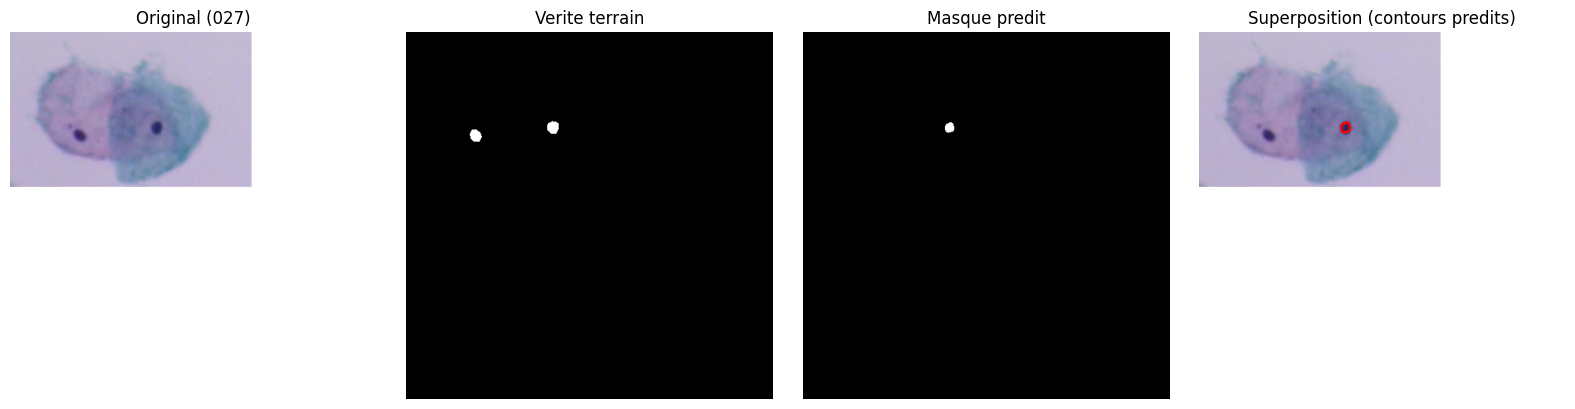

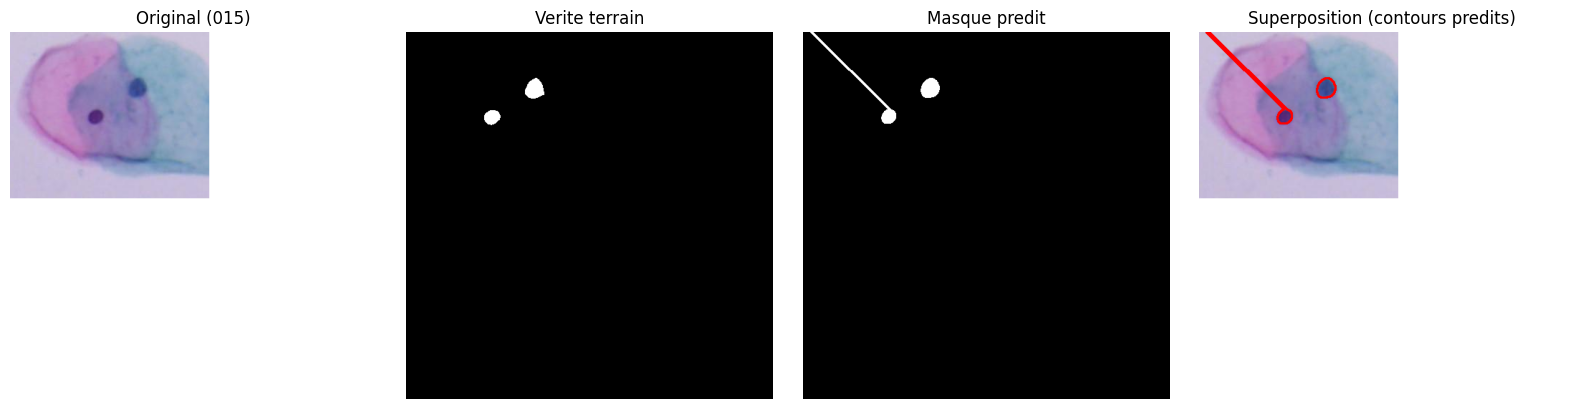

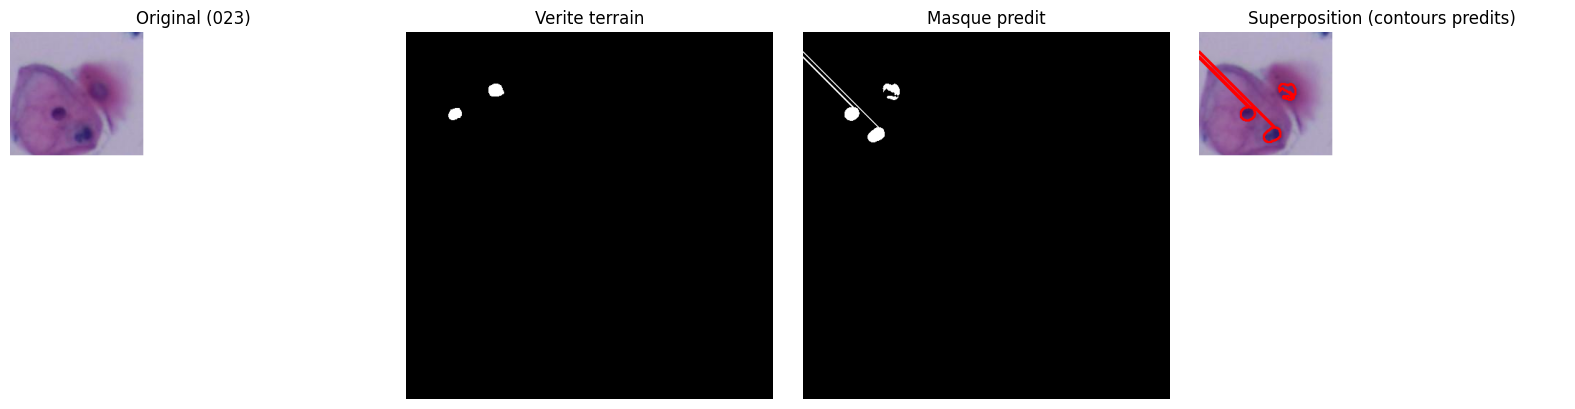

In [8]:
import matplotlib.pyplot as plt

def show_segmentation_examples(split_name: str, n_examples: int = 3):
    inst_maps = seg_results[split_name]["inst_maps"]
    gt_root = Path(CONFIG["paths"]["cx22_gt_root"])
    shown = 0
    for slide_id, pred_mask in inst_maps.items():
        if shown >= n_examples:
            break
        gt_path = find_ground_truth_mask(gt_root, slide_id)
        image_path = next(Path(CONFIG["paths"]["cx22_images"]).rglob(f"{slide_id}.*"), None)
        if gt_path is None or image_path is None:
            continue
        original = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
        gt_mask = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.resize(gt_mask, (pred_mask.shape[1], pred_mask.shape[0]), interpolation=cv2.INTER_NEAREST)

        overlay = original.copy()
        contours, _ = cv2.findContours((pred_mask > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        axes[0].imshow(original); axes[0].set_title(f"Original ({slide_id})"); axes[0].axis("off")
        axes[1].imshow(gt_mask, cmap="gray"); axes[1].set_title("Verite terrain"); axes[1].axis("off")
        axes[2].imshow(pred_mask > 0, cmap="gray"); axes[2].set_title("Masque predit"); axes[2].axis("off")
        axes[3].imshow(overlay); axes[3].set_title("Superposition (contours predits)"); axes[3].axis("off")
        plt.tight_layout(); plt.show()
        shown += 1

    if shown == 0:
        print(f"[{split_name}] Aucun exemple avec masque verite-terrain disponible pour la visualisation.")


show_segmentation_examples("test", n_examples=3)


## 3. Classification (EfficientNet-B0) - dataset centralise

Le dataset de classification est **fusionne des le depart** : SIPaKMeD et Herlev sont
combines en un seul jeu de donnees, sur lequel un unique modele est entraine. Il n'y a
plus de notion de site separe, de comparaison, ni d'entrainement par source - c'est le
seul et unique chemin de classification de ce notebook.


### 3.1 Distribution des classes (dataset fusionne)

Premiere etape avant tout entrainement : la distribution reelle, apres fusion, de ce sur
quoi le modele va etre entraine.


  [sipakmed] dyskeratotic -> HSIL : dossier retenu=CROPPED, 813 images
  [sipakmed] koilocytotic -> LSIL : dossier retenu=CROPPED, 825 images
  [sipakmed] metaplastic -> NILM : dossier retenu=CROPPED, 793 images
  [sipakmed] parabasal -> NILM : dossier retenu=CROPPED, 787 images
  [sipakmed] superficial-intermediate -> NILM : dossier retenu=CROPPED, 831 images
  [herlev] normal_columnar -> NILM : dossier retenu=normal_columnar, 29 images
  [herlev] normal_intermediate -> NILM : dossier retenu=normal_intermediate, 21 images
  [herlev] normal_superficial : dossier introuvable
  [herlev] light_dysplastic -> LSIL : dossier retenu=light_dysplastic, 54 images
  [herlev] moderate_dysplastic -> HSIL : dossier retenu=moderate_dysplastic, 43 images
  [herlev] severe_dysplastic -> HSIL : dossier retenu=severe_dysplastic, 59 images
  [herlev] carcinoma_in_situ -> SCC : dossier retenu=carcinoma_in_situ, 45 images
Total fusionne : 4300 images


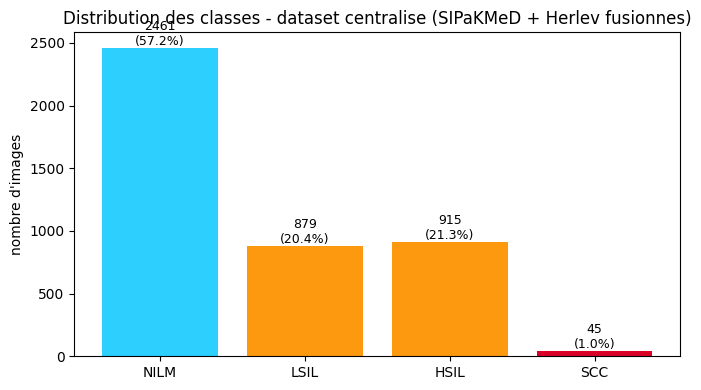

      count  percent
NILM   2461     57.2
LSIL    879     20.4
HSIL    915     21.3
SCC      45      1.0


In [9]:
def load_all_class_samples(cfg: dict):
    """Charge les listes (chemin, label) de toutes les sources, sans transformation -
    sert a l'analyse de distribution et a la construction du dataset fusionne."""
    from PIL import Image

    class_names = cfg["classes"]["names"]

    def _normalize(name):
        return name.strip().lower().replace(" ", "_").replace("-", "_")

    def find_class_directories(root, class_folder_map):
        """MODIFIE : correspondance tolerante (sous-chaine dans un sens ou l'autre)
        au lieu d'une egalite stricte - absorbe les prefixes/suffixes reels des
        dossiers (ex. 'im_dyskeratotic' vs 'dyskeratotic')."""
        normalized_targets = {_normalize(k) for k in class_folder_map}
        found = {}
        for path in root.rglob("*"):
            if not path.is_dir():
                continue
            norm_name = _normalize(path.name)
            for target in normalized_targets:
                if target in norm_name or norm_name in target:
                    found.setdefault(target, path)
        return found

    IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp")

    def find_richest_image_folder(class_dir: Path) -> Path:
        """Au lieu de deviner un nom de sous-dossier ('crop'), on prend celui qui
        contient le plus d'images directement en son sein - c'est presque toujours
        le dossier des cellules deja decoupees, peu importe son nom reel."""
        candidates = [class_dir] + [d for d in class_dir.rglob("*") if d.is_dir()]
        counts = {d: sum(1 for f in d.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS)
                  for d in candidates}
        return max(counts, key=counts.get)

    all_samples = []
    for source in cfg["paths"]["classification_sources"]:
        root = Path(source["images"])
        class_dirs = find_class_directories(root, source["class_folder_map"])
        for raw_name, bethesda_class in source["class_folder_map"].items():
            class_dir = class_dirs.get(_normalize(raw_name))
            if class_dir is None:
                print(f"  [{source['name']}] {raw_name} : dossier introuvable")
                continue
            label_idx = class_names.index(bethesda_class)
            best_folder = find_richest_image_folder(class_dir)
            images_here = [f for f in best_folder.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS]
            print(f"  [{source['name']}] {raw_name} -> {bethesda_class} : "
                  f"dossier retenu={best_folder.name}, {len(images_here)} images")
            for img_path in images_here:
                all_samples.append((img_path, label_idx, source["name"]))
    return all_samples


def analyze_class_distribution(cfg: dict, all_samples: list):
    """Distribution des classes du dataset FUSIONNE (comptes + pourcentages + barres)."""
    class_names = cfg["classes"]["names"]
    labels = [label for _, label, _ in all_samples]
    counts = pd.Series(labels).value_counts().reindex(range(len(class_names)), fill_value=0)
    counts.index = class_names
    pct = 100 * counts / counts.sum()

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(class_names, counts.values, color=["#2DCFFF", "#FC990F", "#FC990F", "#DA0126"])
    for bar, c, p in zip(bars, counts.values, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{c}\n({p:.1f}%)",
                ha="center", va="bottom", fontsize=9)
    ax.set_title("Distribution des classes - dataset centralise (SIPaKMeD + Herlev fusionnes)")
    ax.set_ylabel("nombre d'images")
    plt.tight_layout(); plt.show()

    print(pd.DataFrame({"count": counts, "percent": pct.round(1)}).to_string())
    return counts


all_samples = load_all_class_samples(CONFIG)
print(f"Total fusionne : {len(all_samples)} images")
class_distribution = analyze_class_distribution(CONFIG, all_samples)

### 3.2 Exemples d'images par classe

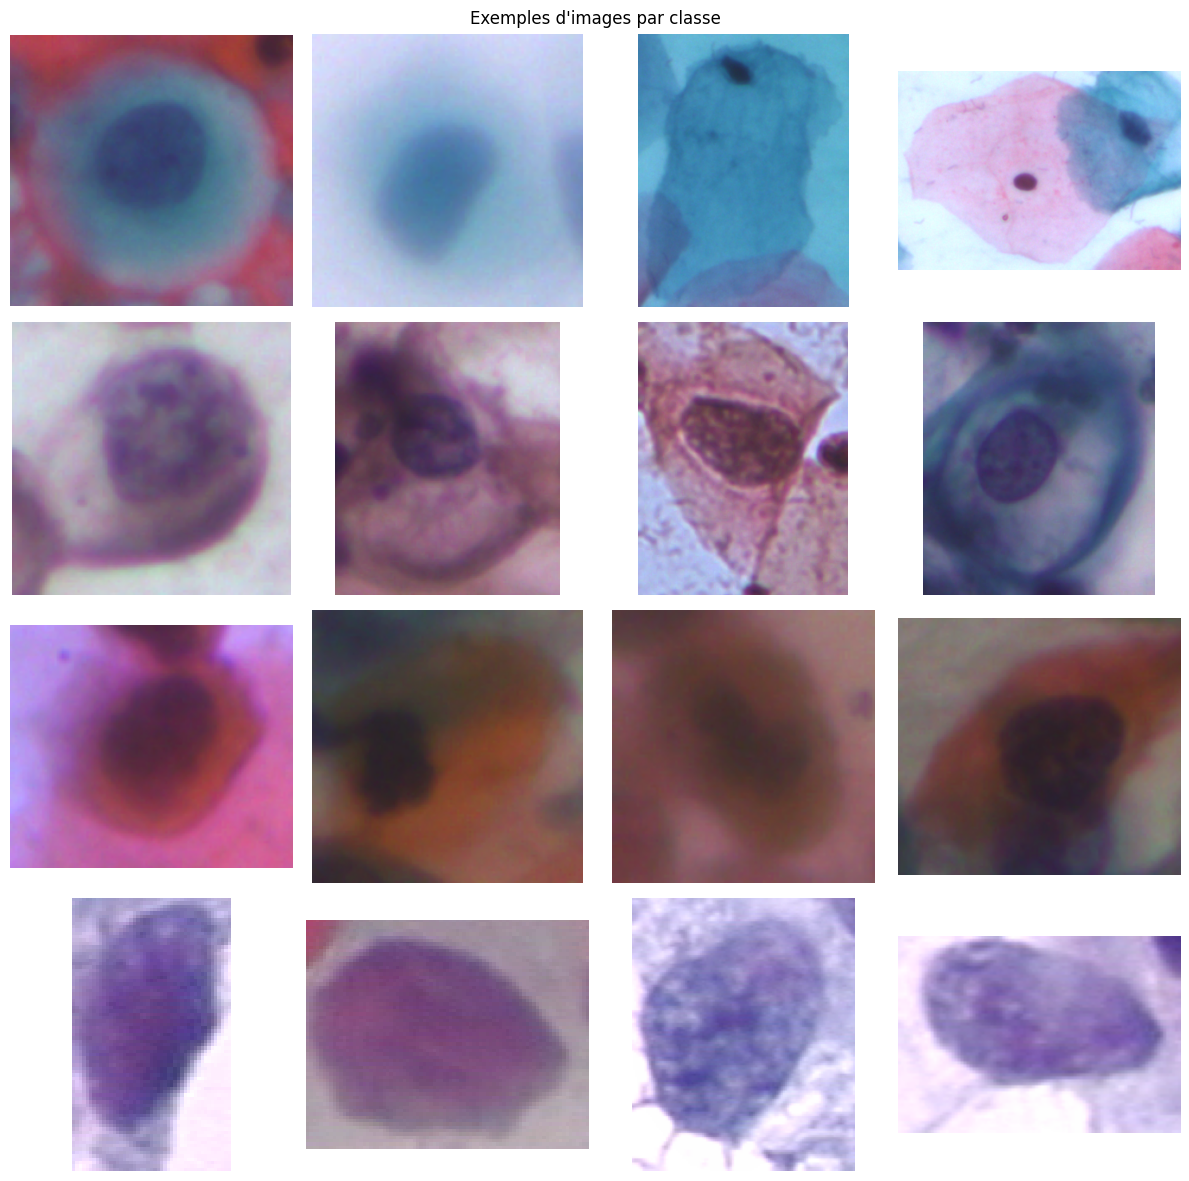

In [10]:
def show_sample_images_per_class(cfg: dict, all_samples: list, n_per_class: int = 4):
    class_names = cfg["classes"]["names"]
    fig, axes = plt.subplots(len(class_names), n_per_class, figsize=(3 * n_per_class, 3 * len(class_names)))
    for class_idx, class_name in enumerate(class_names):
        class_samples = [p for p, label, _ in all_samples if label == class_idx]
        chosen = np.random.choice(len(class_samples), size=min(n_per_class, len(class_samples)), replace=False)
        for col, sample_idx in enumerate(chosen):
            img = cv2.cvtColor(cv2.imread(str(class_samples[sample_idx])), cv2.COLOR_BGR2RGB)
            ax = axes[class_idx, col] if len(class_names) > 1 else axes[col]
            ax.imshow(img); ax.axis("off")
            if col == 0:
                ax.set_ylabel(class_name, fontsize=12, rotation=0, labelpad=40)
    fig.suptitle("Exemples d'images par classe")
    plt.tight_layout(); plt.show()


show_sample_images_per_class(CONFIG, all_samples)


### 3.3 Augmentation de donnees - train uniquement

Transformations choisies specifiquement pour la cytologie, pas des augmentations
generiques de vision par ordinateur : les cellules n'ont pas d'orientation "correcte"
(flip/rotation sans risque), mais une transformation trop agressive (perspective,
deformation elastique, crop extreme) pourrait distordre les structures nucleaires qui
font la difference entre LSIL/HSIL/SCC - evitees ici.

- **Flip horizontal/vertical** + **rotation aleatoire (±15°)** : pas d'orientation
  privilegiee pour une cellule.
- **RandomResizedCrop (85-100%)** : simule un leger decentrage, sans jamais couper une
  portion importante de la cellule.
- **ColorJitter leger** : simule la variabilite de coloration (Papanicolaou) entre
  laboratoires.
- **RandomAffine leger (translation/echelle)** : petites imperfections de centrage, sans
  deformer la morphologie.
- **GaussianBlur leger, optionnel (p=0.2)** : simule une mise au point legerement
  imparfaite, jamais assez fort pour effacer les details nucleaires.

**Validation et test : redimensionnement + normalisation uniquement**, aucune
augmentation - la seule facon d'evaluer honnetement sur des donnees representatives de
l'usage reel.


In [11]:
from torchvision import transforms


def build_transforms(image_size: int, train: bool) -> transforms.Compose:
    if train:
        ops = [
            transforms.RandomResizedCrop(image_size, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))], p=0.2),
        ]
    else:
        ops = [transforms.Resize((image_size, image_size))]
    ops += [transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]
    return transforms.Compose(ops)


### 3.4 Dataset, split stratifie, poids de classe, Focal Loss

**Pas de fuite d'augmentation** : deux `Dataset` distincts (un avec augmentation, un
sans) construits sur la MEME liste `all_samples` (meme ordre, meme contenu) - seuls les
indices different entre train (utilise la version augmentee) et val/test (version
non augmentee).

**Poids de classe** calcules uniquement a partir des labels du train (jamais val/test).

**WeightedRandomSampler vs. loss ponderee** : par defaut on utilise la loss ponderee
seule (`use_weighted_sampler=False`). Cumuler sampler + loss ponderee a pleine intensite
double-corrige le desequilibre (sur-represente les classes rares dans chaque batch ET
les sur-pondere dans le calcul de la perte), ce qui peut degrader la classe majoritaire
et perturber les statistiques BatchNorm (calculees par batch). Si vous activez
`use_weighted_sampler=True`, la ponderation de la loss est desactivee automatiquement.

**Focal Loss** : utile en complement du desequilibre de classe pur, car LSIL/HSIL se
ressemblent visuellement (exemples "durs"). Reduit le poids des exemples faciles/deja
bien classes pour concentrer le gradient sur les exemples difficiles.


In [12]:
!pip uninstall -y -q laplace laplace-torch curvlinops-for-pytorch
!pip install --no-cache-dir --force-reinstall -q --no-deps "curvlinops-for-pytorch==2.0.1"
!pip install --no-cache-dir --force-reinstall -q --no-deps "laplace-torch==0.2.2.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 43.7 MB/s eta 0:00:00


In [13]:
import random

import timm
from laplace import Laplace
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
)
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F  # you'll likely need this too if FocalLoss uses F.cross_entropy / F.log_softmax etc.

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class CentralizedCellDataset(Dataset):
    """Dataset de classification a partir de la liste fusionnee (all_samples).
    `train` controle uniquement quelle transformation est appliquee."""

    def __init__(self, samples: list, image_size: int, train: bool):
        self.samples = samples
        self.transform = build_transforms(image_size, train)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, _source = self.samples[idx]
        return self.transform(Image.open(img_path).convert("RGB")), label


def stratified_train_val_test_split(labels: list, val_fraction: float, test_fraction: float, seed: int):
    """Split stratifie a 3 voies : preserve la proportion de chaque classe dans train/val/test."""
    indices = list(range(len(labels)))
    train_val_idx, test_idx = train_test_split(indices, test_size=test_fraction, stratify=labels, random_state=seed)
    train_val_labels = [labels[i] for i in train_val_idx]
    relative_val_fraction = val_fraction / (1.0 - test_fraction)
    train_idx, val_idx = train_test_split(
        train_val_idx, test_size=relative_val_fraction, stratify=train_val_labels, random_state=seed,
    )
    return train_idx, val_idx, test_idx


def compute_class_weights(labels: list, num_classes: int) -> torch.Tensor:
    """Poids de classe = inverse de la frequence, normalise. Calcule UNIQUEMENT a partir du train."""
    counts = np.bincount(labels, minlength=num_classes).astype(np.float64)
    counts[counts == 0] = 1.0
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


class FocalLoss(nn.Module):
    """Focal Loss (Lin et al., 2017) : reduit le poids des exemples faciles/deja bien
    classes ((1-p)^gamma) pour concentrer le gradient sur les exemples difficiles -
    complementaire de la ponderation alpha par classe."""

    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        log_probs = torch.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        alpha_t = self.alpha.to(logits.device)[targets]
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        return (-alpha_t * (1 - pt) ** self.gamma * log_pt).mean()


def build_efficientnet_b0(num_classes: int, pretrained: bool = True) -> nn.Module:
    return timm.create_model("efficientnet_b0", pretrained=pretrained, num_classes=num_classes)


class BayesianCellClassifier:
    """Backbone MAP + Last-Layer Laplace Approximation post-hoc (laplace-torch)."""

    def __init__(self, backbone: nn.Module, cfg: dict):
        laplace_cfg = cfg["classification"]["laplace"]
        self.backbone = backbone
        self.la = Laplace(backbone, likelihood="classification",
                           subset_of_weights=laplace_cfg["subset_of_weights"],
                           hessian_structure=laplace_cfg["hessian_structure"],
                           prior_precision=laplace_cfg["prior_precision"])

    def fit(self, train_loader: DataLoader):
        self.la.fit(train_loader)
        self.la.optimize_prior_precision()

    @torch.no_grad()
    def predict_posterior(self, images: torch.Tensor, n_samples: int = 30) -> dict:
        """Echantillonnage Monte Carlo depuis le posterior Laplace de la derniere
        couche : mu = probabilite moyenne par classe (calibree), sigma = incertitude
        (ecart-type entre echantillons) - c'est ce qui distingue ce pipeline d'une
        simple classification softmax, et ce qui permet de signaler les cas
        incertains plutot que de deviner silencieusement."""
        samples = self.la.predictive_samples(images, n_samples=n_samples)
        return {"mu": samples.mean(dim=0), "sigma": samples.std(dim=0)}

    def save(self, path: str):
        torch.save(self.la.state_dict(), path)


def compute_classification_metrics(model: nn.Module, loader: DataLoader, device: torch.device, class_names: list) -> dict:
    """Accuracy, precision/recall/F1 macro, specificite macro, AUC/AUPRC macro,
    matrice de confusion, classification report, et les scores bruts (pour ROC/PR)."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            probs = torch.softmax(model(images.to(device)), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_preds.append(probs.argmax(axis=1))
            all_labels.append(labels.numpy())
    y_true, y_pred, y_prob = np.concatenate(all_labels), np.concatenate(all_preds), np.concatenate(all_probs)
    n_classes = len(class_names)
    y_true_onehot = np.eye(n_classes)[y_true]
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))

    # Specificite par classe = TN / (TN + FP), a partir de la matrice de confusion
    specificities = []
    total = cm.sum()
    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp
        specificities.append(tn / (tn + fp + 1e-8))

    metrics = {
        "accuracy": float((y_pred == y_true).mean()),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "specificity_macro": float(np.mean(specificities)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "confusion_matrix": cm,
        "classification_report": classification_report(y_true, y_pred, labels=list(range(n_classes)),
                                                         target_names=class_names, zero_division=0),
        "y_true": y_true, "y_prob": y_prob,  # conserves pour les courbes ROC/PR
    }
    try:
        metrics["auc_macro"] = float(roc_auc_score(y_true_onehot, y_prob, average="macro", multi_class="ovr"))
        metrics["auprc_macro"] = float(average_precision_score(y_true_onehot, y_prob, average="macro"))
    except ValueError:
        metrics["auc_macro"], metrics["auprc_macro"] = float("nan"), float("nan")
    return metrics


|2026-07-21|04:51:05.646| [INFO] Asdfghjkl backend not available since the old asdfghjkl dependency is not installed. If you want to use it, run: pip install git+https://git@github.com/wiseodd/asdl@asdfghjkl


### 3.5 Entrainement - early stopping, scheduler, meilleur modele

**Selection du meilleur modele : F1-macro**, pas accuracy - avec des classes tres
desequilibrees, un modele qui predit presque toujours NILM peut avoir une bonne accuracy
tout en ratant les cas graves. F1-macro pese chaque classe egalement.

**ReduceLROnPlateau** reduit le LR quand le F1-macro de validation stagne.
**Early stopping** arrete l'entrainement apres `early_stopping_patience` epoques sans
amelioration. **Evaluation finale sur le TEST set**, jamais touche pendant
l'entrainement ni la selection du meilleur modele.


In [14]:
def train_classifier(cfg: dict, all_samples: list, device: torch.device) -> dict:
    c_cfg = cfg["classification"]
    class_names = cfg["classes"]["names"]
    set_all_seeds(c_cfg["seed"])

    labels = [label for _, label, _ in all_samples]
    train_idx, val_idx, test_idx = stratified_train_val_test_split(
        labels, c_cfg["val_fraction"], c_cfg["test_fraction"], c_cfg["seed"],
    )

    dataset_aug = CentralizedCellDataset(all_samples, c_cfg["image_size"], train=True)
    dataset_plain = CentralizedCellDataset(all_samples, c_cfg["image_size"], train=False)
    train_set = Subset(dataset_aug, train_idx)
    val_set = Subset(dataset_plain, val_idx)
    test_set = Subset(dataset_plain, test_idx)

    train_labels = [labels[i] for i in train_idx]
    class_weights = compute_class_weights(train_labels, c_cfg["num_classes"])
    print(f"Poids de classe (train uniquement) : {dict(zip(class_names, class_weights.tolist()))}")

    if c_cfg["use_weighted_sampler"]:
        sample_weights = [class_weights[l].item() for l in train_labels]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        train_loader = DataLoader(train_set, batch_size=c_cfg["batch_size"], sampler=sampler, num_workers=2)
        loss_alpha = torch.ones(c_cfg["num_classes"])
    else:
        train_loader = DataLoader(train_set, batch_size=c_cfg["batch_size"], shuffle=True, num_workers=2)
        loss_alpha = class_weights

    val_loader = DataLoader(val_set, batch_size=c_cfg["batch_size"], shuffle=False, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=c_cfg["batch_size"], shuffle=False, num_workers=2)

    criterion = (FocalLoss(alpha=loss_alpha, gamma=c_cfg["focal_gamma"]) if c_cfg["loss_type"] == "focal"
                 else nn.CrossEntropyLoss(weight=loss_alpha.to(device)))

    model = build_efficientnet_b0(c_cfg["num_classes"], c_cfg["pretrained"]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=c_cfg["lr"], weight_decay=c_cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=c_cfg["lr_scheduler_patience"],
    )

    out_dir = Path(cfg["paths"]["outputs_root"]) / "classification"
    out_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = out_dir / "efficientnet_b0_map.pt"

    history = {"train_losses": [], "val_accs": [], "val_f1_macros": []}
    best_val_f1, epochs_without_improvement = 0.0, 0

    for epoch in range(c_cfg["epochs"]):
        model.train()
        running_loss = 0.0
        for images, labels_batch in tqdm(train_loader, desc=f"epoch {epoch + 1}/{c_cfg['epochs']}"):
            images, labels_batch = images.to(device), labels_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_set)
        val_metrics = compute_classification_metrics(model, val_loader, device, class_names)
        scheduler.step(val_metrics["f1_macro"])
        history["train_losses"].append(train_loss)
        history["val_accs"].append(val_metrics["accuracy"])
        history["val_f1_macros"].append(val_metrics["f1_macro"])
        print(f"epoch {epoch + 1}: train_loss={train_loss:.4f} val_acc={val_metrics['accuracy']:.4f} "
              f"val_f1_macro={val_metrics['f1_macro']:.4f} lr={optimizer.param_groups[0]['lr']:.2e}")

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1, epochs_without_improvement = val_metrics["f1_macro"], 0
            torch.save({"state_dict": model.state_dict(), "class_names": class_names}, ckpt_path)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= c_cfg["early_stopping_patience"]:
                print(f"Early stopping a l'epoque {epoch + 1}")
                break

    print(f"\nMeilleur val_f1_macro={best_val_f1:.4f} -> {ckpt_path}")
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=False)["state_dict"])
    test_metrics = compute_classification_metrics(model, test_loader, device, class_names)
    print("\n=== Evaluation sur le TEST set ===")
    print(f"accuracy={test_metrics['accuracy']:.4f}  precision_macro={test_metrics['precision_macro']:.4f}  "
          f"recall_macro={test_metrics['recall_macro']:.4f}  specificity_macro={test_metrics['specificity_macro']:.4f}  "
          f"f1_macro={test_metrics['f1_macro']:.4f}  auc_macro={test_metrics['auc_macro']:.4f}  "
          f"auprc_macro={test_metrics['auprc_macro']:.4f}")
    print(test_metrics["classification_report"])

    bayesian_model = BayesianCellClassifier(model, cfg)
    bayesian_model.fit(DataLoader(train_set, batch_size=c_cfg["batch_size"], shuffle=False, num_workers=2))
    bayesian_model.save(str(out_dir / "laplace_state.pt"))
    print(f"Tete bayesienne (Laplace) ajustee -> {out_dir / 'laplace_state.pt'}")

    history.update({"best_val_f1_macro": best_val_f1, "test_metrics": test_metrics,
                     "model": model, "class_names": class_names, "bayesian_model": bayesian_model,
                     "test_set": test_set, "test_idx": test_idx})
    return history


### Execution de l'entrainement

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

classification_history = train_classifier(CONFIG, all_samples, device)


Device : cuda
Poids de classe (train uniquement) : {'NILM': 0.4367382526397705, 'LSIL': 1.2235772609710693, 'HSIL': 1.1739469766616821, 'SCC': 24.274192810058594}
|2026-07-21|04:51:19.002| [INFO] Loading pretrained weights from Hugging Face hub (timm/efficientnet_b0.ra_in1k)
|2026-07-21|04:51:19.058| [INFO] HTTP Request: HEAD https://huggingface.co/timm/efficientnet_b0.ra_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
|2026-07-21|04:51:19.077| [INFO] HTTP Request: GET https://huggingface.co/api/models/timm/efficientnet_b0.ra_in1k/xet-read-token/1b5383e5f79cc0f7fc067e372f8f26a5fa73f26a "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

|2026-07-21|04:51:21.514| [INFO] [timm/efficientnet_b0.ra_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
|2026-07-21|04:51:21.537| [INFO] Missing keys (classifier.weight, classifier.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


epoch 1/15: 100%|██████████| 48/48 [00:10<00:00,  4.37it/s]


epoch 1: train_loss=3.8927 val_acc=0.6016 val_f1_macro=0.4724 lr=3.00e-04


...

epoch 14: train_loss=0.1868 val_acc=0.9287 val_f1_macro=0.8756 lr=3.00e-04


epoch 15/15: 100%|██████████| 48/48 [00:04<00:00,  9.65it/s]


epoch 15: train_loss=0.2123 val_acc=0.9318 val_f1_macro=0.8802 lr=3.00e-04

Meilleur val_f1_macro=0.8802 -> /kaggle/working/outputs/classification/efficientnet_b0_map.pt

=== Evaluation sur le TEST set ===
accuracy=0.8977  precision_macro=0.7532  recall_macro=0.7519  specificity_macro=0.9659  f1_macro=0.7472  auc_macro=0.9891  auprc_macro=0.8741
              precision    recall  f1-score   support

        NILM       0.99      0.90      0.94       369
        LSIL       0.75      0.93      0.83       132
        HSIL       0.88      0.89      0.88       137
         SCC       0.40      0.29      0.33         7

    accuracy                           0.90       645
   macro avg       0.75      0.75      0.75       645
weighted avg       0.91      0.90      0.90       645



|2026-07-21|04:53:04.415| [WARNING] /usr/local/lib/python3.12/dist-packages/laplace/baselaplace.py:435: UserWarning: By default `link_approx` is `probit`. Make sure to set it equals to the way you want to call `la(test_data, pred_type=..., link_approx=...)`.
  warnings.warn(



Tete bayesienne (Laplace) ajustee -> /kaggle/working/outputs/classification/laplace_state.pt


## 4. Evaluation et visualisations completes

Courbes d'entrainement, matrice de confusion, courbes ROC et Precision-Recall (one-vs-rest,
une courbe par classe), et un graphique en barres du precision/recall/F1 par classe.


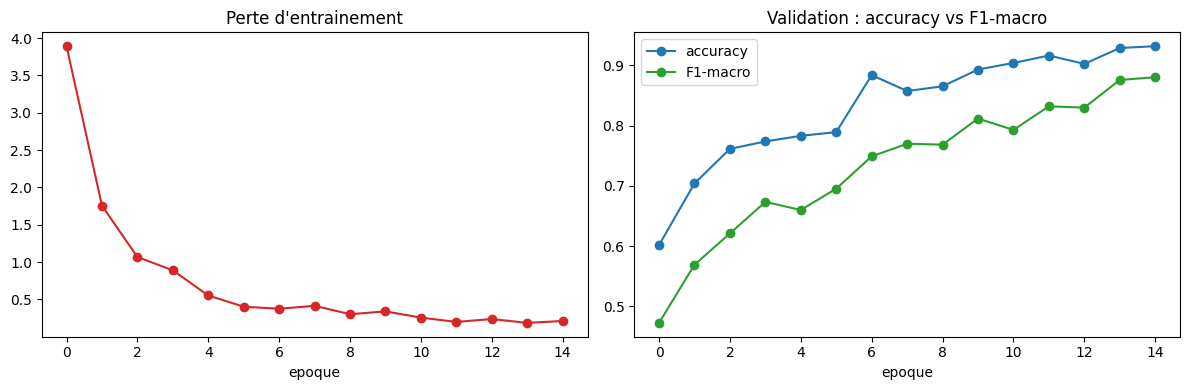

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(classification_history["train_losses"], marker="o", color="tab:red")
axes[0].set_title("Perte d'entrainement"); axes[0].set_xlabel("epoque")
axes[1].plot(classification_history["val_accs"], marker="o", label="accuracy", color="tab:blue")
axes[1].plot(classification_history["val_f1_macros"], marker="o", label="F1-macro", color="tab:green")
axes[1].set_title("Validation : accuracy vs F1-macro"); axes[1].set_xlabel("epoque"); axes[1].legend()
plt.tight_layout(); plt.show()


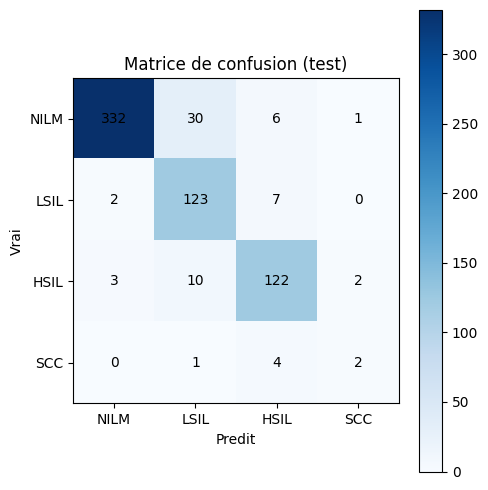

In [17]:
test_metrics = classification_history["test_metrics"]
class_names = classification_history["class_names"]

# --- Matrice de confusion ---
cm = test_metrics["confusion_matrix"]
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names)
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel("Predit"); ax.set_ylabel("Vrai"); ax.set_title("Matrice de confusion (test)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar(im); plt.tight_layout(); plt.show()


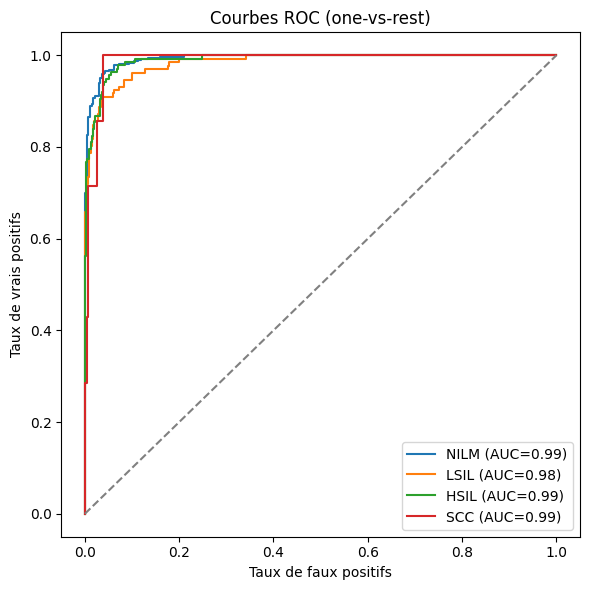

In [18]:
# --- Courbes ROC (one-vs-rest, une courbe par classe) ---
y_true_onehot = np.eye(len(class_names))[test_metrics["y_true"]]
y_prob = test_metrics["y_prob"]

fig, ax = plt.subplots(figsize=(6, 6))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_prob[:, i])
    auc_i = roc_auc_score(y_true_onehot[:, i], y_prob[:, i]) if y_true_onehot[:, i].sum() > 0 else float("nan")
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_i:.2f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("Taux de faux positifs"); ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC (one-vs-rest)"); ax.legend()
plt.tight_layout(); plt.show()


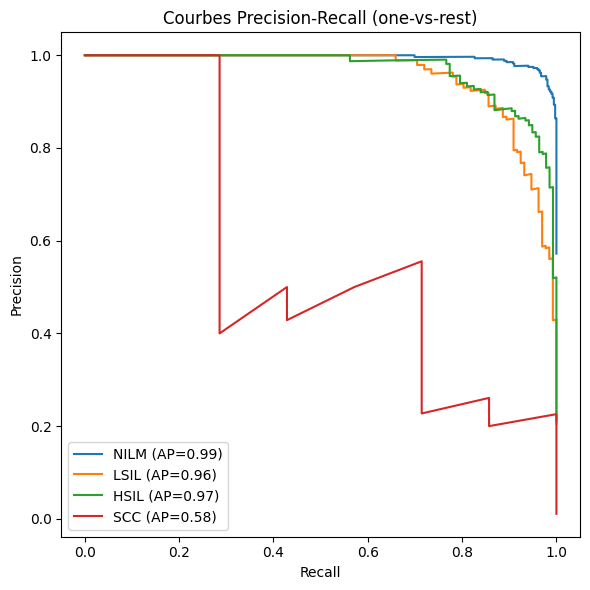

In [19]:
# --- Courbes Precision-Recall (one-vs-rest, une courbe par classe) ---
fig, ax = plt.subplots(figsize=(6, 6))
for i, name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_true_onehot[:, i], y_prob[:, i])
    ap_i = average_precision_score(y_true_onehot[:, i], y_prob[:, i]) if y_true_onehot[:, i].sum() > 0 else float("nan")
    ax.plot(recall, precision, label=f"{name} (AP={ap_i:.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Courbes Precision-Recall (one-vs-rest)"); ax.legend()
plt.tight_layout(); plt.show()


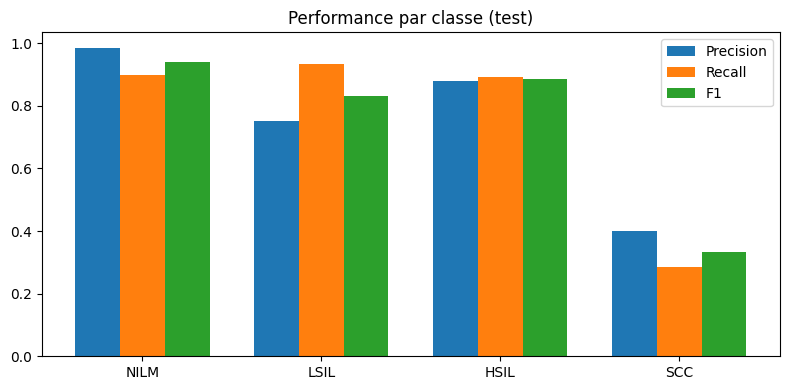

In [20]:
# --- Precision / Recall / F1 par classe (barres groupees) ---
per_class_precision = precision_score(test_metrics["y_true"], y_prob.argmax(axis=1), average=None, zero_division=0)
per_class_recall = recall_score(test_metrics["y_true"], y_prob.argmax(axis=1), average=None, zero_division=0)
per_class_f1 = f1_score(test_metrics["y_true"], y_prob.argmax(axis=1), average=None, zero_division=0)

x = np.arange(len(class_names))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width, per_class_precision, width, label="Precision")
ax.bar(x, per_class_recall, width, label="Recall")
ax.bar(x + width, per_class_f1, width, label="F1")
ax.set_xticks(x); ax.set_xticklabels(class_names)
ax.set_title("Performance par classe (test)"); ax.legend()
plt.tight_layout(); plt.show()


### Incertitude bayesienne (Laplace) sur le test set

**Pourquoi cette section existe.** Le modele n'est pas juste un classifieur softmax : une
tete bayesienne (approximation de Laplace, derniere couche) a ete ajustee en plus, et
donne pour chaque prediction un `sigma` (incertitude), pas seulement une classe. Ce
qu'on verifie ici : **une prediction incorrecte a-t-elle, en moyenne, un sigma plus
eleve qu'une prediction correcte ?** Si oui, la tete bayesienne capture reellement une
incertitude utile (elle pourrait servir a signaler les cas douteux a un expert plutot
que de se fier a un score aveugle) - un chiffre isole comme "précision 93%" ne le montre
pas, il faut regarder specifiquement le comportement du sigma.


Sigma moyen (predictions CORRECTES)   : 0.0989
Sigma moyen (predictions INCORRECTES) : 0.2577
(si le second chiffre est plus eleve que le premier, l'incertitude bayesienne
 est bien informative - elle est plus elevee exactement quand le modele se trompe)


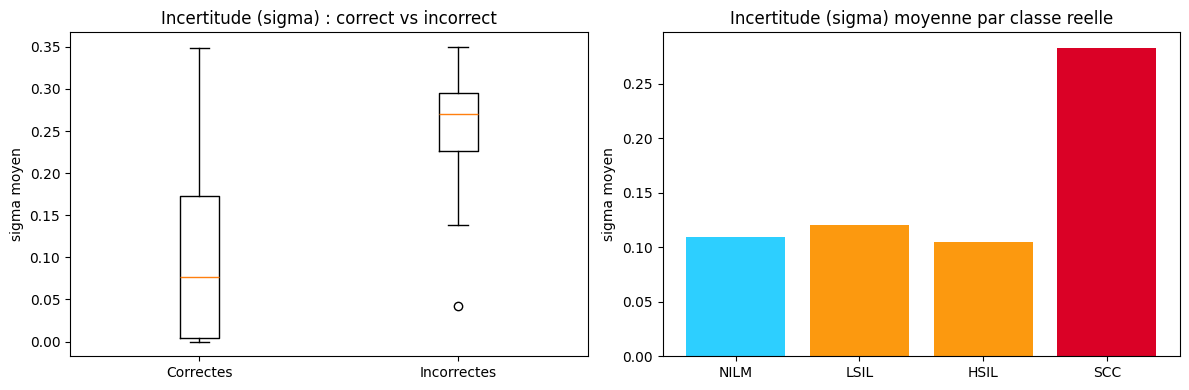

In [21]:
bayesian_model = classification_history["bayesian_model"]
test_set = classification_history["test_set"]
class_names = classification_history["class_names"]

test_loader_for_uncertainty = DataLoader(test_set, batch_size=CONFIG["classification"]["batch_size"],
                                          shuffle=False, num_workers=2)

all_mu, all_sigma, all_true = [], [], []
for images, labels in test_loader_for_uncertainty:
    posterior = bayesian_model.predict_posterior(images.to(device), n_samples=30)
    all_mu.append(posterior["mu"].cpu().numpy())
    all_sigma.append(posterior["sigma"].cpu().numpy())
    all_true.append(labels.numpy())

mu = np.concatenate(all_mu)
sigma = np.concatenate(all_sigma)
y_true_unc = np.concatenate(all_true)
y_pred_unc = mu.argmax(axis=1)
mean_sigma_per_sample = sigma.mean(axis=1)  # incertitude moyenne toutes classes confondues

is_correct = (y_pred_unc == y_true_unc)
print(f"Sigma moyen (predictions CORRECTES)   : {mean_sigma_per_sample[is_correct].mean():.4f}")
print(f"Sigma moyen (predictions INCORRECTES) : {mean_sigma_per_sample[~is_correct].mean():.4f}")
print("(si le second chiffre est plus eleve que le premier, l'incertitude bayesienne")
print(" est bien informative - elle est plus elevee exactement quand le modele se trompe)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([mean_sigma_per_sample[is_correct], mean_sigma_per_sample[~is_correct]],
                tick_labels=["Correctes", "Incorrectes"])
axes[0].set_title("Incertitude (sigma) : correct vs incorrect"); axes[0].set_ylabel("sigma moyen")

sigma_by_class = pd.Series(mean_sigma_per_sample).groupby(y_true_unc).mean()
sigma_by_class.index = [class_names[i] for i in sigma_by_class.index]
axes[1].bar(sigma_by_class.index, sigma_by_class.values, color=["#2DCFFF", "#FC990F", "#FC990F", "#DA0126"])
axes[1].set_title("Incertitude (sigma) moyenne par classe reelle"); axes[1].set_ylabel("sigma moyen")
plt.tight_layout(); plt.show()


## 5. Explicabilite (Grad-CAM)

Plusieurs exemples par classe : image originale, heatmap Grad-CAM, superposition,
classe predite, classe reelle, et probabilite de confiance.

**Couche cible : `blocks.2`, pas `conv_head`** - sur des crops de 64x64, `conv_head`
(apres 32x de sous-echantillonnage) ne laisse qu'une grille ~2x2, insuffisante pour un
Grad-CAM localisant reellement quelque chose. `blocks.2` (sous-echantillonnage 8x) donne
une carte 8x8, avec une vraie structure spatiale a afficher.


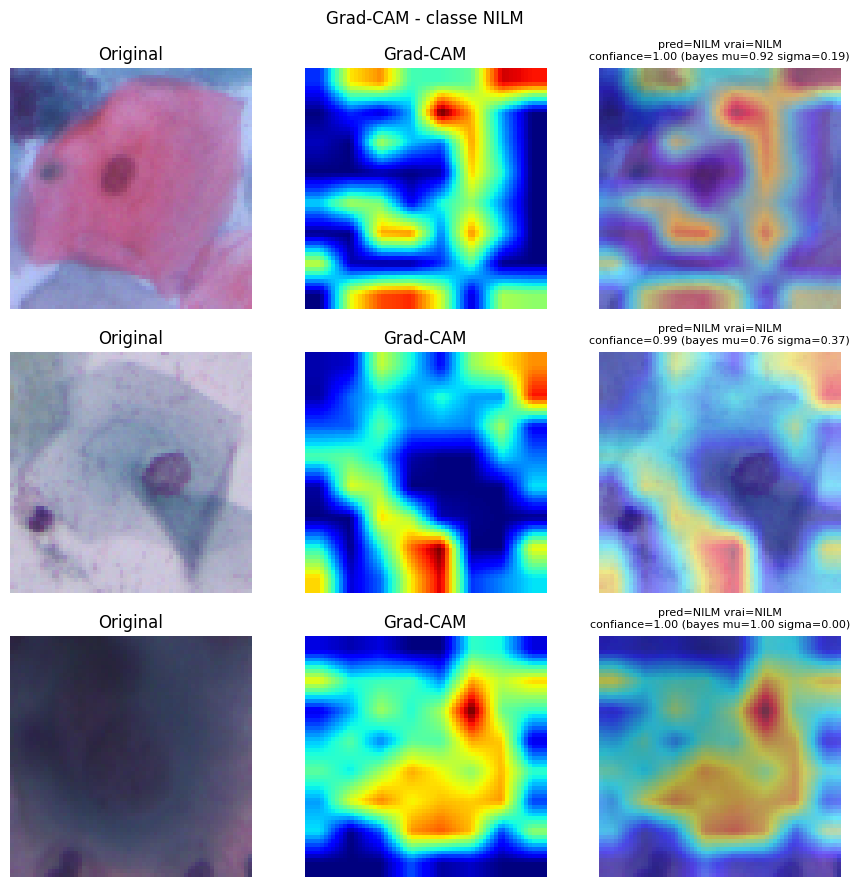

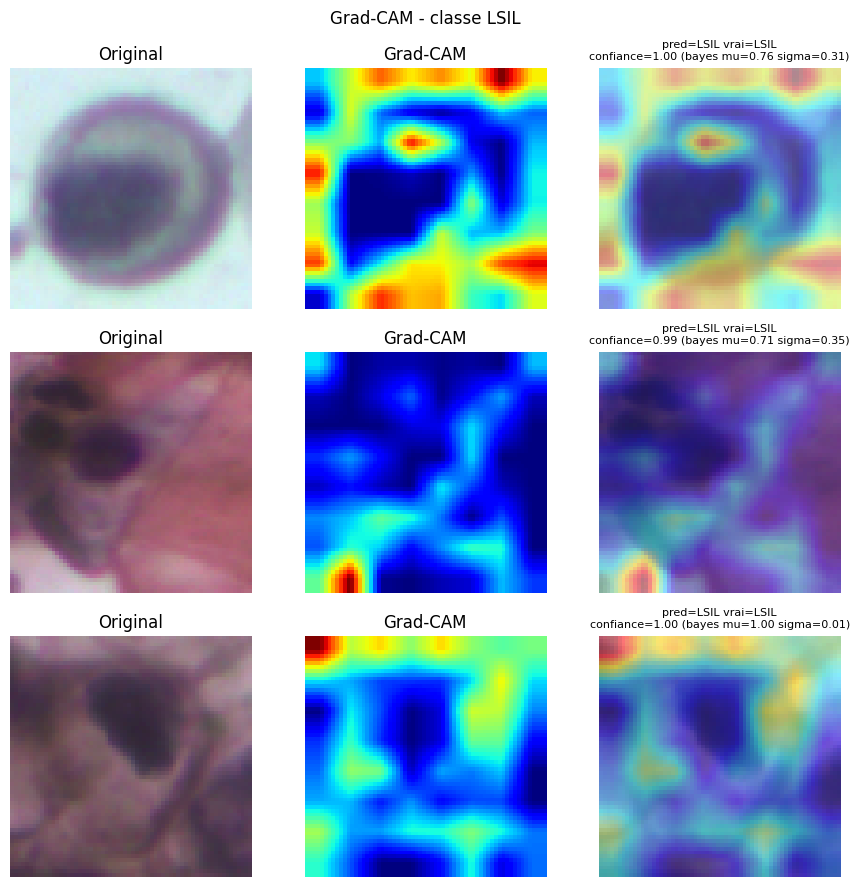

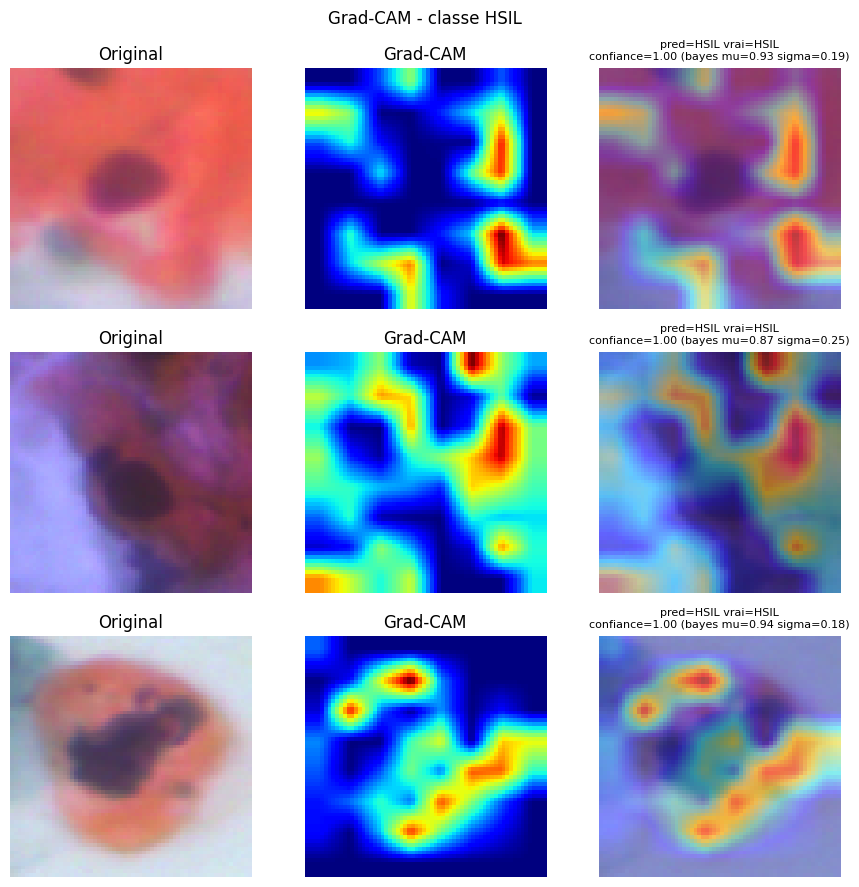

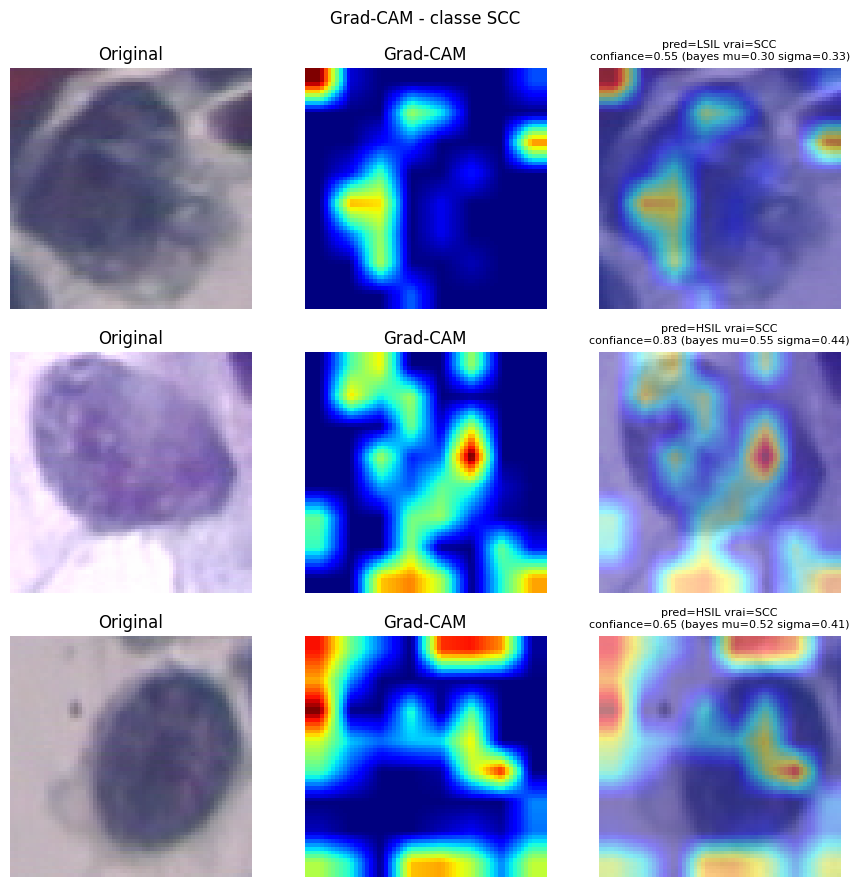

In [22]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def compute_gradcam(model, target_layer_name, image_tensor, target_class_idx):
    target_layer = dict(model.named_modules())[target_layer_name]
    with GradCAM(model=model, target_layers=[target_layer]) as cam:
        grayscale_cam = cam(input_tensor=image_tensor, targets=[ClassifierOutputTarget(target_class_idx)])
    return grayscale_cam[0]


def show_gradcam_examples(cfg: dict, model, bayesian_model, all_samples: list, test_idx: list, device: torch.device):
    e_cfg, class_names = cfg["explainability"], cfg["classes"]["names"]
    image_size = cfg["classification"]["image_size"]
    transform = build_transforms(image_size, train=False)
    model.eval()

    test_samples_by_class = {i: [] for i in range(len(class_names))}
    for idx in test_idx:
        _, label, _ = all_samples[idx]
        test_samples_by_class[label].append(idx)

    for class_idx, class_name in enumerate(class_names):
        candidates = test_samples_by_class[class_idx]
        if not candidates:
            print(f"Aucun exemple de test pour la classe {class_name}.")
            continue
        chosen = np.random.choice(candidates, size=min(e_cfg["num_examples_per_class"], len(candidates)), replace=False)

        fig, axes = plt.subplots(len(chosen), 3, figsize=(9, 3 * len(chosen)))
        if len(chosen) == 1:
            axes = axes.reshape(1, 3)
        for row, idx in enumerate(chosen):
            img_path, true_label, _ = all_samples[idx]
            original = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
            original_resized = cv2.resize(original, (image_size, image_size))
            image_tensor = transform(Image.fromarray(original)).unsqueeze(0).to(device)

            with torch.no_grad():
                probs = torch.softmax(model(image_tensor), dim=1)[0].cpu().numpy()
            pred_idx = int(probs.argmax())

            # Incertitude bayesienne (Laplace) pour ce meme exemple - complement au
            # score softmax brut : sigma eleve = le modele n'est pas vraiment sur.
            posterior = bayesian_model.predict_posterior(image_tensor, n_samples=30)
            bayes_mu = posterior["mu"][0].cpu().numpy()
            bayes_sigma = posterior["sigma"][0].cpu().numpy()

            cam = compute_gradcam(model, e_cfg["gradcam_target_layer"], image_tensor, pred_idx)
            overlay = show_cam_on_image(original_resized.astype(np.float32) / 255.0, cam, use_rgb=True, image_weight=0.6)

            axes[row, 0].imshow(original_resized); axes[row, 0].set_title("Original"); axes[row, 0].axis("off")
            axes[row, 1].imshow(cam, cmap="jet"); axes[row, 1].set_title("Grad-CAM"); axes[row, 1].axis("off")
            axes[row, 2].imshow(overlay)
            axes[row, 2].set_title(f"pred={class_names[pred_idx]} vrai={class_names[true_label]}\n"
                                    f"confiance={probs[pred_idx]:.2f} (bayes mu={bayes_mu[pred_idx]:.2f} "
                                    f"sigma={bayes_sigma[pred_idx]:.2f})", fontsize=8)
            axes[row, 2].axis("off")
        fig.suptitle(f"Grad-CAM - classe {class_name}")
        plt.tight_layout(); plt.show()


labels_all = [label for _, label, _ in all_samples]
_, _, test_idx_for_gradcam = stratified_train_val_test_split(
    labels_all, CONFIG["classification"]["val_fraction"], CONFIG["classification"]["test_fraction"],
    CONFIG["classification"]["seed"],
)
show_gradcam_examples(CONFIG, classification_history["model"], classification_history["bayesian_model"],
                       all_samples, test_idx_for_gradcam, device)


## Recapitulatif

Ordre d'execution : installation -> verification d'environnement -> configuration ->
segmentation (Cx22, split + evaluation + visualisations qualitatives) -> classification
(dataset centralise, gestion du desequilibre complete, entrainement avec early
stopping/scheduler) -> evaluation complete (courbes, matrice de confusion, ROC,
Precision-Recall, performance par classe) -> Grad-CAM (plusieurs exemples par classe).

Pipeline centralise de bout en bout, un seul dataset fusionne, un seul modele.


In [23]:
import json
import shutil

bundle_dir = Path(CONFIG["paths"]["outputs_root"]) / "model_bundle"
bundle_dir.mkdir(parents=True, exist_ok=True)

classification_dir = Path(CONFIG["paths"]["outputs_root"]) / "classification"
shutil.copy(classification_dir / "efficientnet_b0_map.pt", bundle_dir / "efficientnet_b0.pt")
shutil.copy(classification_dir / "laplace_state.pt", bundle_dir / "laplace_state.pt")

json.dump({
    "classes": CONFIG["classes"]["names"],
    "image_size": CONFIG["classification"]["image_size"],
    "gradcam_target_layer": CONFIG["explainability"]["gradcam_target_layer"],
    "laplace": CONFIG["classification"]["laplace"],
    "hovernet_model": CONFIG["segmentation"]["model"],           # <- ajoute
    "patch_size": CONFIG["segmentation"]["patch_size"],           # <- ajoute
    "min_nucleus_area": CONFIG["segmentation"]["min_nucleus_area"],  # <- ajoute
}, open(bundle_dir / "inference_config.json", "w"), indent=2)

print("Bundle pret :", list(bundle_dir.iterdir()))

Bundle pret : [PosixPath('/kaggle/working/outputs/model_bundle/inference_config.json'), PosixPath('/kaggle/working/outputs/model_bundle/laplace_state.pt'), PosixPath('/kaggle/working/outputs/model_bundle/efficientnet_b0.pt')]


In [26]:
from tiatoolbox.models.architecture import fetch_pretrained_weights

hovernet_weights_path = fetch_pretrained_weights(
    CONFIG["segmentation"]["model"],  # "hovernet_fast-pannuke"
    save_path=str(bundle_dir / "hovernet_fast-pannuke.pth"),
    overwrite=True,
)
print("Poids HoVer-Net copies dans le bundle ->", hovernet_weights_path)
print("Bundle complet :", list(bundle_dir.iterdir()))

|2026-07-21|05:02:49.844| [INFO] HTTP Request: HEAD https://huggingface.co/TIACentre/TIAToolbox_pretrained_weights/resolve/main/hovernet_fast-pannuke.pth "HTTP/1.1 302 Found"
|2026-07-21|05:02:49.862| [INFO] HTTP Request: GET https://huggingface.co/api/models/TIACentre/TIAToolbox_pretrained_weights/xet-read-token/ea909bdcce3aa409bf436c09b4495cca90a8e99b "HTTP/1.1 200 OK"


hovernet_fast-pannuke.pth:   0%|          | 0.00/151M [00:00<?, ?B/s]

Poids HoVer-Net copies dans le bundle -> /kaggle/working/outputs/model_bundle/hovernet_fast-pannuke.pth/hovernet_fast-pannuke.pth
Bundle complet : [PosixPath('/kaggle/working/outputs/model_bundle/inference_config.json'), PosixPath('/kaggle/working/outputs/model_bundle/hovernet_fast-pannuke.pth'), PosixPath('/kaggle/working/outputs/model_bundle/laplace_state.pt'), PosixPath('/kaggle/working/outputs/model_bundle/efficientnet_b0.pt')]


AttributeError: 'str' object has no attribute 'st_size'

In [27]:
!zip -r folder.zip /kaggle/working/outputs/model_bundle

updating: kaggle/working/outputs/model_bundle/ (stored 0%)
updating: kaggle/working/outputs/model_bundle/inference_config.json (deflated 36%)
updating: kaggle/working/outputs/model_bundle/laplace_state.pt (deflated 75%)
updating: kaggle/working/outputs/model_bundle/efficientnet_b0.pt (deflated 8%)
  adding: kaggle/working/outputs/model_bundle/hovernet_fast-pannuke.pth/ (stored 0%)
  adding: kaggle/working/outputs/model_bundle/hovernet_fast-pannuke.pth/.cache/ (stored 0%)
  adding: kaggle/working/outputs/model_bundle/hovernet_fast-pannuke.pth/.cache/huggingface/ (stored 0%)
  adding: kaggle/working/outputs/model_bundle/hovernet_fast-pannuke.pth/.cache/huggingface/.gitignore (stored 0%)
  adding: kaggle/working/outputs/model_bundle/hovernet_fast-pannuke.pth/.cache/huggingface/CACHEDIR.TAG (deflated 24%)
  adding: kaggle/working/outputs/model_bundle/hovernet_fast-pannuke.pth/.cache/huggingface/download/ (stored 0%)
  adding: kaggle/working/outputs/model_bundle/hovernet_fast-pannuke.pth/.c

In [28]:
from IPython.display import FileLink
FileLink(r'folder.zip')

/kaggle/working/folder.zip